In [1]:
from pathlib import Path

RTL_DIR = Path('./rtl-model')
CPP_DIR = Path('./cpp-model')
OCTAVE_DIR = Path('./octave-model')
VER_DIR = Path('./verilator')

!tree -d

.
├── cpp-model
├── octave-model
├── rtl-model
│   └── obj_dir
├── vendor
│   └── ac_types
│       ├── gdb
│       ├── include
│       ├── pdfdocs
│       └── rlsinfo
├── verilator
│   └── obj_dir
└── vis

14 directories


## TASK I - Octave (+ LUT optimization uzing Chebyshev approximation)

In [2]:
import sys
from decimal import Decimal

def convert_to_hpp(input_file, output_file):
    try:
        with open(input_file, 'r') as f:
            lines = f.readlines()
    except FileNotFoundError:
        print(f"Błąd: Nie znaleziono pliku {input_file}")
        sys.exit(1)

    data_lines = [line for line in lines if line.strip() and not line.startswith('#')]
    table_size = len(data_lines)

    out_lines = [
        f"const double CoeffTable [{table_size}][4] =",
        "{",
        "//      k                                  a                                  b                                  c"
    ]

    for i, line in enumerate(data_lines):
        parts = line.split()
        if len(parts) < 4:
            continue
            
        k = int(parts[0])
        a = Decimal(parts[1])
        b = Decimal(parts[2])
        c = Decimal(parts[3])
        
        row_str = f"    {{ {k:3d}, {a: 32.28f}, {b: 32.28f}, {c: 32.28f} }}"
        
        if i < len(data_lines) - 1:
            row_str += ","
            
        out_lines.append(row_str)

    out_lines.append("};")

    with open(output_file, 'w') as f:
        f.write('\n'.join(out_lines) + '\n')

In [3]:
import pandas as pd
import re

def parse_output_to_df(text):
    pattern = r"(\w+)\s*=\s*([-+]?[\d.eE+-]+)"
    
    matches = re.findall(pattern, text)
    
    data = []
    current_row = {}
    
    for key, value in matches:
        current_row[key] = float(value)
        
        if key == "y_err":
            data.append(current_row)
            current_row = {}
            
    return pd.DataFrame(data)

/home/jgolaszewski/intel/octave-model
Running octave script: approx_tayl.m...


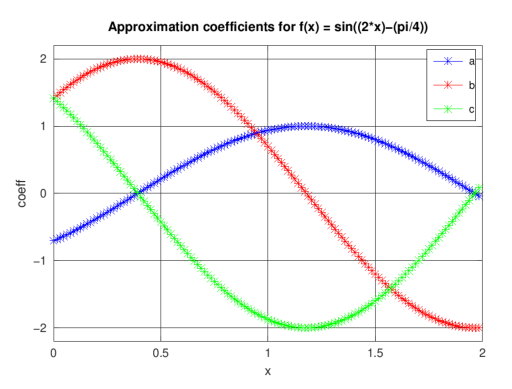

/home/jgolaszewski/intel/cpp-model
--- Error statistics for approx_tayl.m ---


,max,mean,std,min
y_err,2.180000e-07,7.477719e-08,5.114303e-08,4.290000e-13


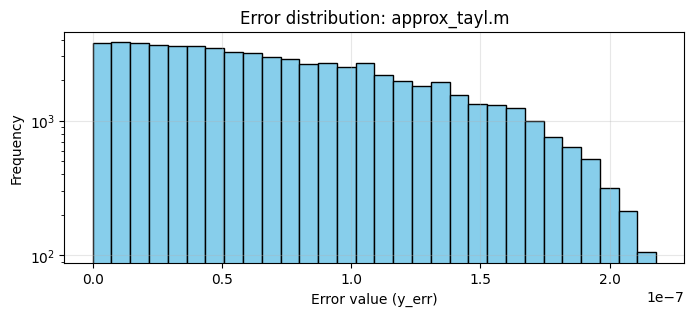

/home/jgolaszewski/intel/octave-model
Running octave script: approx_cheb.m...


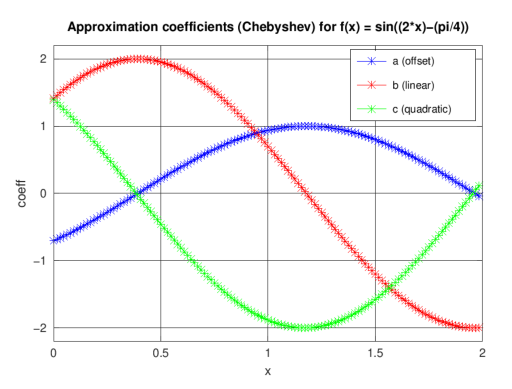

/home/jgolaszewski/intel/cpp-model
--- Error statistics for approx_cheb.m ---


,max,mean,std,min
y_err,2.180000e-07,7.477719e-08,5.114303e-08,4.290000e-13


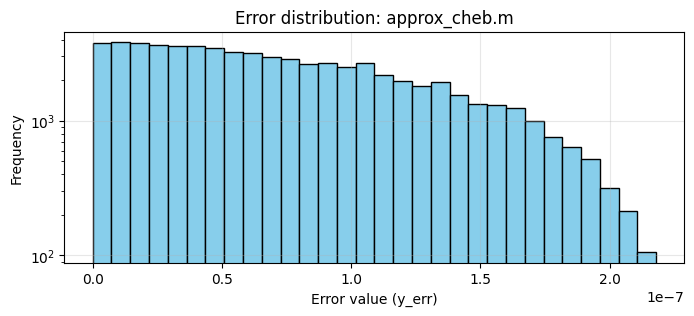

/home/jgolaszewski/intel/octave-model
/home/jgolaszewski/intel


In [4]:
import matplotlib.pyplot as plt
from PIL import Image
import subprocess

CPP_EXE_NAME = "./QuadraTb"

%cd ./octave-model/
lut_octave_exec = ['approx_tayl.m', 'approx_cheb.m']
lut_octave_coeffs = ['lut_coeffs_taylor.txt', 'lut_coeffs_chebyshev.txt']
lut_octave_plot = ['plot_taylor_coeffs.png', 'plot_chebyshev_coeffs.png']

for exe, coeffs, plot in zip(lut_octave_exec, lut_octave_coeffs, lut_octave_plot):
    print(f'Running octave script: {exe}...')
    !./{exe} > /dev/null 2>&1
    plt.imshow(Image.open(plot))
    plt.axis('off')
    plt.show()

    
    %cd ../cpp-model/

    subprocess.run(["make", "check-lut"], capture_output=True, text=True)
    run = subprocess.run([CPP_EXE_NAME, "--step", "0x1000"], capture_output=True, text=True)

    df = parse_output_to_df(run.stdout)

    error_stats = df['y_err'].agg(['max', 'mean', 'std', 'min']).to_frame().T
    
    print(f"--- Error statistics for {exe} ---")
    display(error_stats)

    plt.figure(figsize=(8, 3))
    plt.hist(df['y_err'], bins=30, color='skyblue', edgecolor='black')
    plt.title(f'Error distribution: {exe}')
    plt.xlabel('Error value (y_err)')
    plt.ylabel('Frequency')
    plt.yscale('log')
    plt.grid(True, alpha=0.3)
    plt.show()

    %cd ../octave-model/


# Using Chebyshev coeff.
coeff_f = 'lut_coeffs_chebyshev.txt'
convert_to_hpp(coeff_f, '../cpp-model/CoeffTable.hpp')

%cd ..

## TASK II 

In [5]:
import subprocess
import re
import pandas as pd
from itertools import product
from tqdm import tqdm

MODEL_DIR = "cpp-model"
EXE_NAME = "QuadraTb"

def parse_output_to_df(text):
    pattern = r"(\w+)\s*=\s*([-+]?[\d.eE+-]+)"
    matches = re.findall(pattern, text)
    
    data = []
    current_row = {}
    
    for key, value in matches:
        current_row[key] = float(value)
        if key == "y_err":
            data.append(current_row)
            current_row = {}
            
    return pd.DataFrame(data)

bit_range = [14,16,18,20]
AI, BI, CI = 2, 3, 3
TARGET_ERROR = 2.15e-6

results_list = []

print("Starting optimization, please wait...\n")

combinations = list(product(bit_range, bit_range, bit_range))

for af, bf, cf in tqdm(combinations, desc="Processing configs", unit="config"):
    cmd_make = [
        "make", "-C", MODEL_DIR, "opt-script",
        f"A_I_VAL={AI}", f"A_F_VAL={af}",
        f"B_I_VAL={BI}", f"B_F_VAL={bf}",
        f"C_I_VAL={CI}", f"C_F_VAL={cf}"
    ]
    subprocess.run(cmd_make, capture_output=True, text=True)

    full_exe_path = f"{MODEL_DIR}/{EXE_NAME}" if "/" not in EXE_NAME else EXE_NAME
    run = subprocess.run([full_exe_path, "--step", "0x1000"], capture_output=True, text=True)
    
    raw_df = parse_output_to_df(run.stdout + run.stderr)
    
    if not raw_df.empty:
        max_err = raw_df["y_err"].max()
        total_bits = af + bf + cf
        status = "PASS" if max_err < TARGET_ERROR else "FAIL"
        
        results_list.append({
            "A_F": af,
            "B_F": bf,
            "C_F": cf,
            "Max_Error": max_err,
            "Total_Bits": total_bits,
            "Status": status
        })

df = pd.DataFrame(results_list)

print("\nFULL EXPERIMENT RESULTS:")
print(df.to_string(index=False))

print("-" * 60)

df_pass = df[df["Status"] == "PASS"].sort_values(by=["Total_Bits", "Max_Error"])

if not df_pass.empty:
    best = df_pass.iloc[0]
    print(best.to_frame().T.to_string(index=False))
else:
    print(f"⚠️ None of the tested configurations achieved an error below {TARGET_ERROR}.")

Starting optimization, please wait...



Processing configs: 100%|██████████| 64/64 [02:13<00:00,  2.08s/config]


FULL EXPERIMENT RESULTS:
 A_F  B_F  C_F    Max_Error  Total_Bits Status
  14   14   14 3.080000e-05          42   FAIL
  14   14   16 3.080000e-05          44   FAIL
  14   14   18 3.080000e-05          46   FAIL
  14   14   20 3.080000e-05          48   FAIL
  14   16   14 3.070000e-05          44   FAIL
  14   16   16 3.070000e-05          46   FAIL
  14   16   18 3.070000e-05          48   FAIL
  14   16   20 3.070000e-05          50   FAIL
  14   18   14 3.080000e-05          46   FAIL
  14   18   16 3.080000e-05          48   FAIL
  14   18   18 3.080000e-05          50   FAIL
  14   18   20 3.080000e-05          52   FAIL
  14   20   14 3.080000e-05          48   FAIL
  14   20   16 3.080000e-05          50   FAIL
  14   20   18 3.080000e-05          52   FAIL
  14   20   20 3.080000e-05          54   FAIL
  16   14   14 8.010000e-06          44   FAIL
  16   14   16 8.020000e-06          46   FAIL
  16   14   18 8.020000e-06          48   FAIL
  16   14   20 8.020000e-06       

Saved: plot_cost_vs_error.png
Saved: plot_individual_params.png
Done!


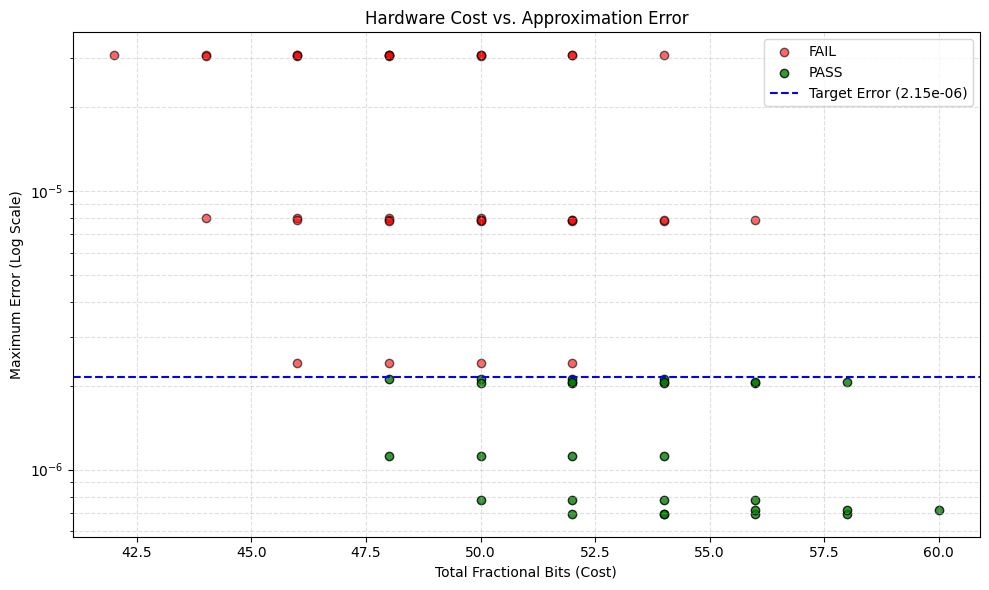

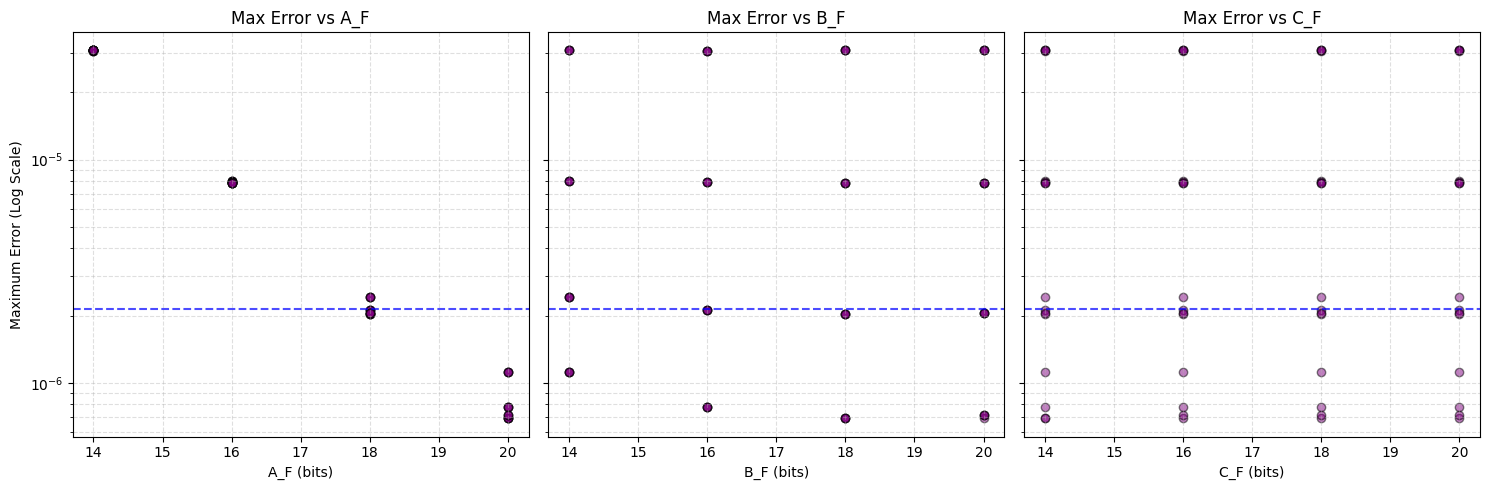

In [6]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
pass_df = df[df["Status"] == "PASS"]
fail_df = df[df["Status"] == "FAIL"]

plt.scatter(fail_df["Total_Bits"], fail_df["Max_Error"], color='red', label='FAIL', alpha=0.6, edgecolors='k')
plt.scatter(pass_df["Total_Bits"], pass_df["Max_Error"], color='green', label='PASS', alpha=0.8, edgecolors='k')

plt.axhline(y=TARGET_ERROR, color='blue', linestyle='--', label=f'Target Error ({TARGET_ERROR:.2e})')

plt.yscale('log')
plt.xlabel("Total Fractional Bits (Cost)")
plt.ylabel("Maximum Error (Log Scale)")
plt.title("Hardware Cost vs. Approximation Error")
plt.legend()
plt.grid(True, which="both", ls="--", alpha=0.4)
plt.tight_layout()
plt.savefig("plot_cost_vs_error.png", dpi=300)
print("Saved: plot_cost_vs_error.png")

fig, axes = plt.subplots(1, 3, figsize=(15, 5), sharey=True)
params = ["A_F", "B_F", "C_F"]

for i, param in enumerate(params):
    axes[i].scatter(df[param], df["Max_Error"], alpha=0.5, c='purple', edgecolors='k')
    axes[i].axhline(y=TARGET_ERROR, color='blue', linestyle='--', alpha=0.7)
    axes[i].set_yscale('log')
    axes[i].set_xlabel(f"{param} (bits)")
    axes[i].set_title(f"Max Error vs {param}")
    axes[i].grid(True, which="both", ls="--", alpha=0.4)

axes[0].set_ylabel("Maximum Error (Log Scale)")
plt.tight_layout()
plt.savefig("plot_individual_params.png", dpi=300)
print("Saved: plot_individual_params.png")

print("Done!")

In [7]:
import plotly.express as px

print("\nGenerating interactive 3D plot with Plotly...")

color_map = {'PASS': '#00CC96', 'FAIL': '#EF553B'}

fig = px.scatter_3d(
    df, 
    x='A_F', 
    y='B_F', 
    z='C_F',
    color='Status',
    color_discrete_map=color_map,
    title='Interactive 3D Design Space: Hardware Configurations',
    labels={'A_F': 'A_F (bits)', 'B_F': 'B_F (bits)', 'C_F': 'C_F (bits)'},
    hover_data=['Max_Error', 'Total_Bits'] # To pokaże się w dymku po najechaniu myszką!
)

fig.update_traces(marker=dict(size=6, opacity=0.8, line=dict(width=1, color='DarkSlateGrey')))
fig.show()


Generating interactive 3D plot with Plotly...


## TASK III - RTL model

**Exemplary model:**

![circuit](./vis/quadratic-interpolator.png)

### Designed model diagram

In [8]:
import math

def get_hex_width(bits):
    return math.ceil(bits / 4)

AW, AF = int(best['A_F']) + AI, int(best['A_F'])
BW, BF = int(best['B_F']) + BI, int(best['B_F'])
CW, CF = int(best['C_F']) + CI, int(best['C_F'])

fmt_a = f"0{get_hex_width(AW)}X"
fmt_b = f"0{get_hex_width(BW)}X"
fmt_c = f"0{get_hex_width(CW)}X"

output_file = "./rtl-model/lut.vs"

with open(output_file, "w") as out:
    out.write('`include "quadra.vh"\n\n') 
    out.write("module lut (\n")
    out.write("    input  x1_t x1,\n")
    out.write("    output a_t  a,\n")
    out.write("    output b_t  b,\n")
    out.write("    output c_t  c\n")
    out.write(");\n\n")
    out.write("always_comb unique casez (x1)\n")

    with open(f"./octave-model/{coeff_f}", "r") as f:
        lines = f.readlines()[1:]
        for line in lines:
            parts = line.split()
            if len(parts) >= 4:
                k = int(parts[0])
                a_fl, b_fl, c_fl = float(parts[1]), float(parts[2]), float(parts[3])
                
                a_int = int(round(a_fl * (1 << AF)))
                b_int = int(round(b_fl * (1 << BF)))
                c_int = int(round(c_fl * (1 << CF)))
                
                a_val = a_int & ((1 << AW) - 1)
                b_val = b_int & ((1 << BW) - 1)
                c_val = c_int & ((1 << CW) - 1)
                
                out.write(f"    7'd{k:<3} : begin ")
                out.write(f"a = {AW}'h{format(a_val, fmt_a)}; ")
                out.write(f"b = {BW}'h{format(b_val, fmt_b)}; ")
                out.write(f"c = {CW}'h{format(c_val, fmt_c)}; ")
                out.write("end\n")

    out.write("    default : begin a = 'x; b = 'x; c = 'x; end\n")
    out.write("endcase\n")
    out.write("endmodule\n")

In [9]:
%%bash
(cd rtl-model && \
yosys -p "read_verilog -sv -I. \
    quadra_top.vs \
    quadra.vs \
    lut.vs \
    square.vs; \
    prep -top quadra_top; write_json ../vis/schema.json")

netlistsvg ./vis/schema.json -o ./vis/schema_quadra.svg


 /----------------------------------------------------------------------------\
 |  yosys -- Yosys Open SYnthesis Suite                                       |
 |  Copyright (C) 2012 - 2026  Claire Xenia Wolf <claire@yosyshq.com>         |
 |  Distributed under an ISC-like license, type "license" to see terms        |
 \----------------------------------------------------------------------------/
 Yosys 0.63 (git sha1 3bc26ff4d055adfbba8b424508ab4a36405ffc0b, g++ 15.2.1 -O2 -flto=auto -ffat-lto-objects -fexceptions -fstack-protector-strong -m64 -march=x86-64 -mtune=generic -fasynchronous-unwind-tables -fstack-clash-protection -fcf-protection -mtls-dialect=gnu2 -fno-omit-frame-pointer -mno-omit-leaf-frame-pointer -fPIC -O3)

-- Running command `read_verilog -sv -I.     quadra_top.vs     quadra.vs     lut.vs     square.vs;     prep -top quadra_top; write_json ../vis/schema.json' --

1. Executing Verilog-2005 frontend: quadra_top.vs
Parsing SystemVerilog input from `quadra_top.vs' to AST

quadra.vs:31: ERROR: Invalid nesting of always blocks and/or initializations.


In [10]:
from IPython.display import HTML

with open("./vis/schema_quadra.svg", "r") as f:
    svg_data = f.read()

display(HTML(f'<div style="background-color: white; padding: 10px; text-align: center;">{svg_data}</div>'))

In [11]:
%%bash
(cd ./rtl-model/ && make all)

verilator --binary --trace --timing +systemverilogext+vs -I. --top-module quadra_tb -f files.f -Wno-fatal -MAKEFLAGS "CXXFLAGS='-std=c++17'"


%Warning-WIDTHTRUNC: quadra.vs:31:78: Operator ASSIGN expects 13 bits on the Assign RHS, but Assign RHS's SHIFTRS generates 35 bits.
                                    : ... note: In instance 'quadra_tb.u0.u_quadra'
   31 |             automatic logic signed [12:0] sq_fxd = $signed({1'b0, x2_sq_un}) >>> 22;
      |                                                                              ^~~
                     ... For warning description see https://verilator.org/warn/WIDTHTRUNC?v=5.036
                     ... Use "/* verilator lint_off WIDTHTRUNC */" and lint_on around source to disable this message.
%Warning-WIDTHEXPAND: quadra.vs:33:69: Operator SHIFTL expects 30 bits on the LHS, but LHS's SIGNED generates 22 bits.
                                     : ... note: In instance 'quadra_tb.u0.u_quadra'
   33 |             automatic logic signed [29:0] t0_fxd = $signed(coeff_a) <<< 7;
      |                                                                     ^~~
                 

make[1]: Entering directory '/home/jgolaszewski/intel/rtl-model/obj_dir'
g++ -Os -std=c++17 -I. -Wall -Wextra -Wfloat-conversion -Wlogical-op -Werror -MMD -I/usr/share/verilator/include -I/usr/share/verilator/include/vltstd -DVM_COVERAGE=0 -DVM_SC=0 -DVM_TIMING=1 -DVM_TRACE=1 -DVM_TRACE_FST=0 -DVM_TRACE_VCD=1 -DVM_TRACE_SAIF=0 -faligned-new -fcf-protection=none -Wno-bool-operation -Wno-shadow -Wno-sign-compare -Wno-subobject-linkage -Wno-tautological-compare -Wno-uninitialized -Wno-unused-but-set-parameter -Wno-unused-but-set-variable -Wno-unused-parameter -Wno-unused-variable    -DVL_TIME_CONTEXT   -fcoroutines -c -o verilated.o /usr/share/verilator/include/verilated.cpp
g++ -Os -std=c++17 -I. -Wall -Wextra -Wfloat-conversion -Wlogical-op -Werror -MMD -I/usr/share/verilator/include -I/usr/share/verilator/include/vltstd -DVM_COVERAGE=0 -DVM_SC=0 -DVM_TIMING=1 -DVM_TRACE=1 -DVM_TRACE_FST=0 -DVM_TRACE_VCD=1 -DVM_TRACE_SAIF=0 -faligned-new -fcf-protection=none -Wno-bool-operation -Wno-sha

Max Error: 0.000001


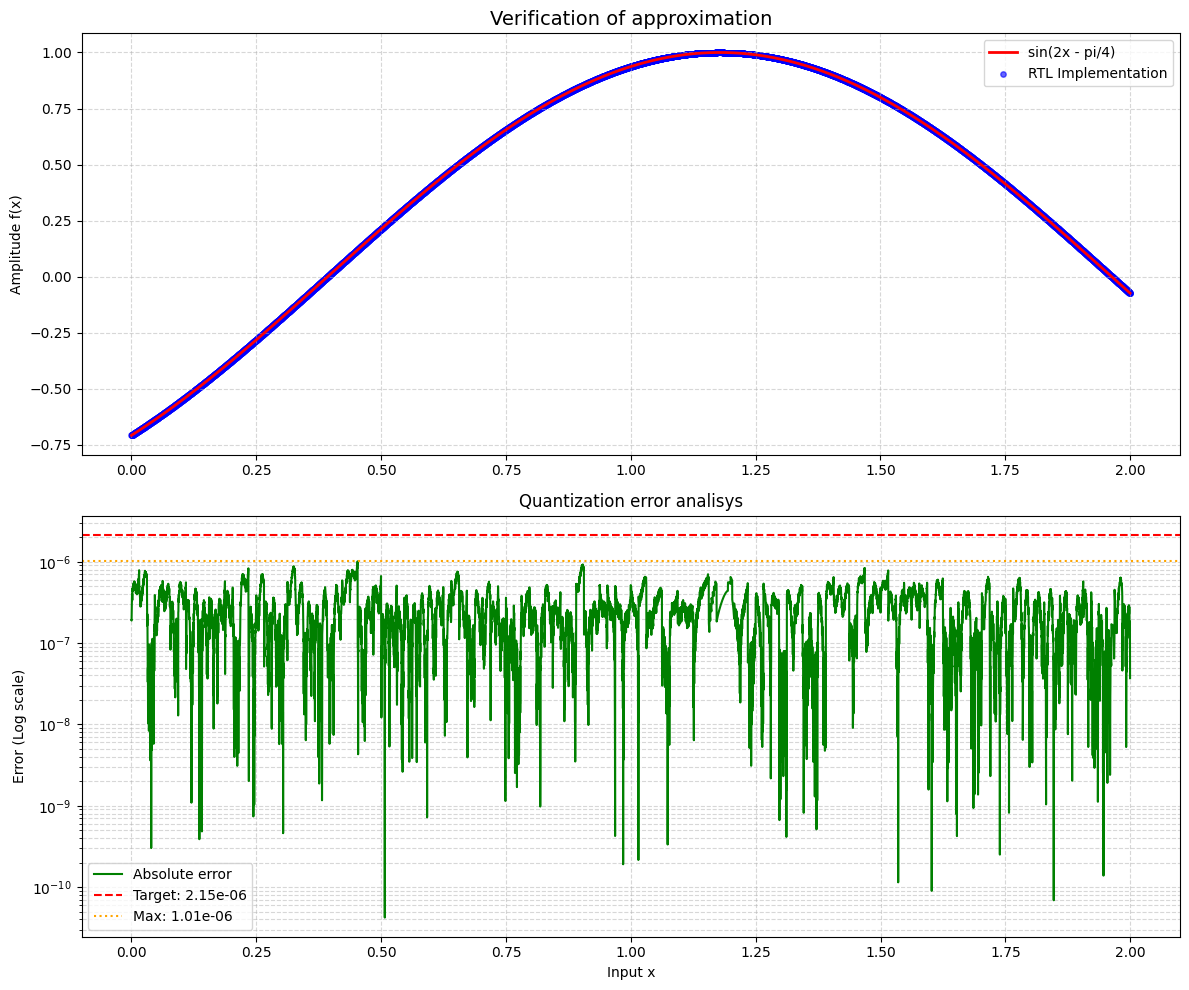

In [12]:
import numpy as np

FRACTIONAL_BITS = 23
FRACTIONAL_BITS_OUT = 23  
Y_WIDTH = 25

def golden_function(x):
    return np.sin(2 * x - np.pi / 4)

def load_rtl_data(filename):
    x_vals = []
    y_vals = []
    try:
        with open(filename, 'r') as f:
            for line in f:
                parts = line.split()
                if len(parts) == 2:
                    x_hex, y_dec = parts[0], parts[1]
                    
                    x_raw = int(x_hex, 16)
                    x_real = x_raw / (2**FRACTIONAL_BITS)
                    
                    y_raw = int(y_dec)
                    if y_raw >= (1 << (Y_WIDTH - 1)):
                        y_raw -= (1 << Y_WIDTH)
                    y_real = y_raw / (2**FRACTIONAL_BITS_OUT)
                    
                    x_vals.append(x_real)
                    y_vals.append(y_real)
        return np.array(x_vals), np.array(y_vals)
    except FileNotFoundError:
        print(f"ERRROR: File not found: {filename}")
        return None, None

x_rtl, y_rtl = load_rtl_data(RTL_DIR / 'rtl_results.txt')

if x_rtl is not None:
    x_ideal = np.linspace(0, 2, 1000)
    y_ideal = golden_function(x_ideal)
    
    y_target = golden_function(x_rtl)
    error = np.abs(y_target - y_rtl)

    plt.figure(figsize=(12, 10))

    plt.subplot(2, 1, 1)
    plt.plot(x_ideal, y_ideal, 'r-', label='sin(2x - pi/4)', linewidth=2)
    plt.scatter(x_rtl, y_rtl, color='blue', s=15, label='RTL Implementation', alpha=0.6)
    plt.title('Verification of approximation', fontsize=14)
    plt.ylabel('Amplitude f(x)')
    plt.legend()
    plt.grid(True, which='both', linestyle='--', alpha=0.5)

    TARGET_ERROR = 2.15e-6

    plt.subplot(2, 1, 2)
    plt.semilogy(x_rtl, error, 'g-', label='Absolute error')
    plt.axhline(y=TARGET_ERROR, color='red', linestyle='--', label=f'Target: {TARGET_ERROR:.2e}')
    plt.axhline(y=np.max(error), color='orange', linestyle=':', label=f'Max: {np.max(error):.2e}')
    plt.title('Quantization error analisys', fontsize=12)
    plt.xlabel('Input x')
    plt.ylabel('Error (Log scale)')
    plt.legend()
    plt.grid(True, which='both', linestyle='--', alpha=0.5)

    plt.tight_layout()
    plt.savefig('./vis/verify-plot.png')
    print(f"Max Error: {np.max(error):.6f}")
    plt.show()

## TASK IV - verilator + GTKW

![](./vis/gtkw.png)

## Python packages

In [13]:
%pip freeze

asttokens==3.0.1
attrs==25.4.0
comm==0.2.3
contourpy==1.3.3
cycler==0.12.1
debugpy==1.8.20
decorator==5.2.1
executing==2.2.1
fastjsonschema==2.21.2
fonttools==4.62.1
ipykernel==7.2.0
ipython==9.11.0
ipython_pygments_lexers==1.1.1
jedi==0.19.2
jsonschema==4.26.0
jsonschema-specifications==2025.9.1
jupyter_client==8.8.0
jupyter_core==5.9.1
kiwisolver==1.5.0
matplotlib==3.10.8
matplotlib-inline==0.2.1
narwhals==2.18.0
nbformat==5.10.4
nest-asyncio==1.6.0
numpy==2.4.3
packaging==26.0
pandas==3.0.1
parso==0.8.6
pexpect==4.9.0
pillow==12.1.1
platformdirs==4.9.4
plotly==6.6.0
prompt_toolkit==3.0.52
psutil==7.2.2
ptyprocess==0.7.0
pure_eval==0.2.3
Pygments==2.19.2
pyparsing==3.3.2
python-dateutil==2.9.0.post0
pyzmq==27.1.0
referencing==0.37.0
rpds-py==0.30.0
six==1.17.0
stack-data==0.6.3
tornado==6.5.5
tqdm==4.67.3
traitlets==5.14.3
wcwidth==0.6.0
Note: you may need to restart the kernel to use updated packages.
